## Sprint 3: Model Architecture, Training, and Evaluation
This notebook covers Sprint 3 of the ASL Language Recognition project. In Sprint 2, the team cleaned the image dataset, created a reproducible train/validation/test split, and built PyTorch DataLoaders for model-ready batches. In Sprint 3, we use those batches to train and evaluate an image classification model.    

Our team uses PyTorch as the deep learning framework for this sprint. The model architecture is based on MobileNetV2 with pretrained ImageNet weights. We apply transfer learning by replacing MobileNetV2’s original 1,000-class classifier with a new classifier that outputs 29 ASL classes. The pretrained layers are frozen first so the model learns the new ASL classifier head before any deeper fine-tuning.    

Team: BeyondWords   
Dataset: ASL Alphabet Language

---
### Load Sprint 2 DataLoader Pipeline

In [1]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


Random seed set to: 42
Cleaned directory exists: True
Cleaned directory path: data/cleaned
Number of folders found: 29
Folders found:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Expected class count: 29
Actual class count: 29
Missing classes: []
Extra classes: []
Total images collected: 87000
Number of classes: 29
Sample record: (PosixPath('data/cleaned/A/A25.jpg'), 0, 'A')
Train samples: 60900
Validation samples: 13050
Test samples: 13050
Total after split: 87000
Train dataset size: 60900
Validation dataset size: 13050
Test dataset size: 13050
Train batches: 1904
Validation batches: 408
Test batches: 408
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


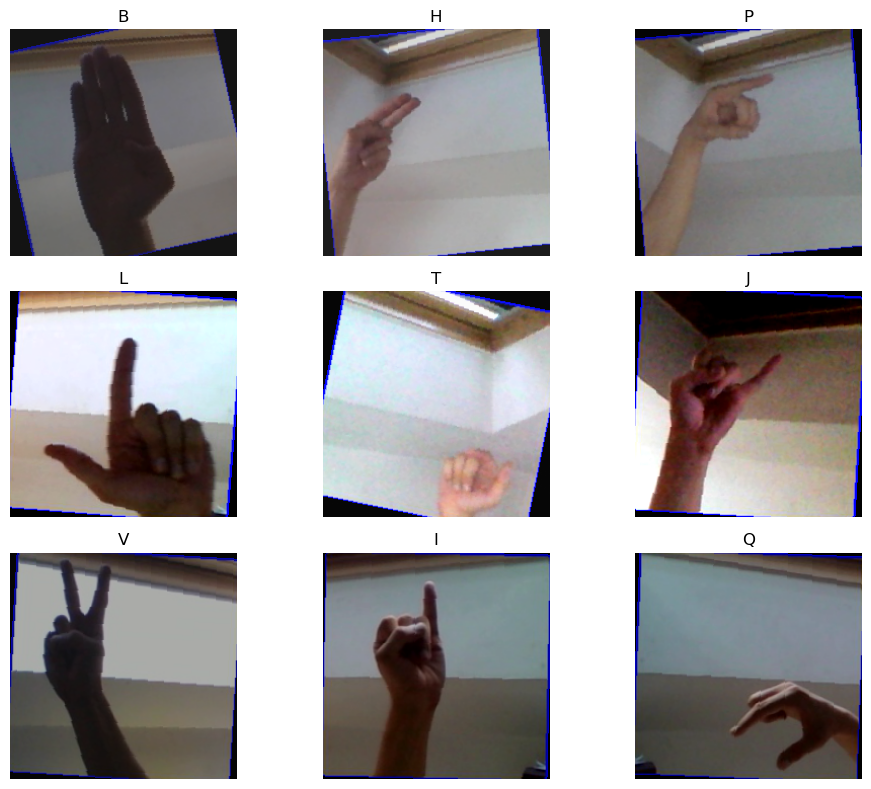

Saved split metadata to: data/asl_dataset_splits.csv
Rows saved: 87000
===== Dataset & DataLoader Verification Summary =====
Cleaned data folder: data/cleaned
Total classes: 29
Total images: 87000

Train images: 60900
Validation images: 13050
Test images: 13050

Batch size: 32
Image size: (224, 224)
Sample batch shape: torch.Size([32, 3, 224, 224])

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

Split metadata saved to: data/asl_dataset_splits.csv


In [2]:
# Run the Sprint 2 DataLoader notebook so train_loader, val_loader, and test_loader are available
%run dataset_dataloader_verification.ipynb

In [3]:
# Confirm DataLoaders are now available in this notebook
[name for name in globals().keys() if "loader" in name.lower()]

['__loader__', 'DataLoader', 'train_loader', 'val_loader', 'test_loader']

---
### TASK 1: **Model Architecture**: MobileNetV2 Transfer Learning
This section defines the model architecture for Sprint 3. We use MobileNetV2 with pretrained ImageNet weights as the base CNN because it already learned useful visual features such as edges, shapes, textures, and object parts. Since our task is ASL image classification, we replace the original 1,000-class ImageNet classifier with a new classifier that outputs 29 ASL classes. We freeze the pretrained feature extractor first so the initial training phase only updates the new classifier layer.

#### <u>Important Concepts:</u>
**Transfer learning** allows us to reuse knowledge from a model that was already trained on a large image dataset. **MobileNetV2** already learned general visual patterns such as edges, shapes, textures, and object parts. For this project, we keep that pretrained feature knowledge and replace only the final classification layer so the model can predict our 29 ASL classes instead of ImageNet classes.

**MobileNetV2** was chosen because it is accurate enough for image classification while being lightweight and efficient. This is useful for our ASL recognition project because hand-sign images do not require an extremely large model, and a smaller architecture trains faster. MobileNetV2 uses inverted residual blocks and depthwise separable convolutions, allowing it to learn useful image features with fewer parameters.

**Freezing** means preventing the pretrained layers from changing during the first training phase. We do this because the pretrained MobileNetV2 layers already contain useful general image knowledge. By freezing those layers, the optimizer only updates the new classifier head first. This makes training faster and reduces the risk of overwriting useful pretrained features too early.

---
### Framework Decision: **PyTorch**

For Sprint 3, our team will use PyTorch as the shared deep learning framework. This matches the Sprint 2 pipeline because our Dataset and DataLoader were already built using `torch.utils.data.Dataset` and `torch.utils.data.DataLoader`. PyTorch also gives us direct control over the training loop, model freezing, optimizer setup, and evaluation process.

### Load Pretrained MobileNetV2

In [4]:
import torch
import torch.nn as nn
from torchvision import models

# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Load MobileNetV2 with pretrained ImageNet weights
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# Move model to selected device
model = model.to(device)

print("MobileNetV2 loaded with pretrained ImageNet weights.")

Using device: cpu
MobileNetV2 loaded with pretrained ImageNet weights.


---
### Replace MobileNetV2 Classifier for 29 ASL Classes

In [5]:
# Number of ASL classes: A-Z plus del, nothing, and space
NUM_CLASSES = 29

# Check the original classifier
print("Original classifier:")
print(model.classifier)

# Get the number of input features going into the final classifier layer
in_features = model.classifier[1].in_features

# Replace the final ImageNet classifier with a new ASL classifier
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

# Move updated model back to device
model = model.to(device)

print("\nUpdated classifier:")
print(model.classifier)
print("\nNumber of output classes:", NUM_CLASSES)

Original classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Updated classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=29, bias=True)
)

Number of output classes: 29


The original MobileNetV2 classifier was designed to output 1,000 ImageNet classes. Since our ASL dataset has 29 classes, we replaced the final linear layer with a new layer that outputs 29 predictions. Each output corresponds to one ASL class.

---
### Freeze Pretrained Feature Extractor

In [6]:
# Freeze all pretrained layers first
for param in model.features.parameters():
    param.requires_grad = False

# Keep the new classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print("Feature extractor frozen.")
print("Classifier head remains trainable.")

Feature extractor frozen.
Classifier head remains trainable.


In [7]:
def count_parameters(model):
    total_params = sum(param.numel() for param in model.parameters())
    trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
    frozen_params = total_params - trainable_params
    
    return total_params, trainable_params, frozen_params


total_params, trainable_params, frozen_params = count_parameters(model)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Frozen parameters:", frozen_params)

Total parameters: 2261021
Trainable parameters: 37149
Frozen parameters: 2223872


After replacing the classifier, we freeze the pretrained feature extractor by setting `requires_grad = False` for the feature layers. This means those layers will not update during the first training phase. Only the new classifier head remains trainable. This setup allows the model to first learn how to map MobileNetV2’s existing visual features to the 29 ASL classes.

---
### Verify Model Output Shape

In [10]:
# Get one batch from the training DataLoader
images, labels = next(iter(train_loader))

# Move images and labels to the same device as the model
images = images.to(device)
labels = labels.to(device)

# Set model to evaluation mode for this shape test
model.eval()

# Disable gradient tracking for this quick check
with torch.no_grad():
    outputs = model(images)

print("Input batch shape:", images.shape)
print("Output batch shape:", outputs.shape)
print("Expected output shape:", (images.shape[0], NUM_CLASSES))

Input batch shape: torch.Size([32, 3, 224, 224])
Output batch shape: torch.Size([32, 29])
Expected output shape: (32, 29)


The model successfully accepts one batch from the training DataLoader with shape `[32, 3, 224, 224]`. This means each batch contains 32 RGB images resized to 224 by 224 pixels. The model returns an output shape of `[32, 29]`, which confirms that MobileNetV2 is producing 29 prediction scores for each image. This matches the 29 ASL classes in our dataset, so the model architecture is ready for training.

---
### Verify frozen and trainable parameters

In [11]:
# Count total, trainable, and frozen parameters
total_params = sum(param.numel() for param in model.parameters())
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {frozen_params:,}")

Total parameters: 2,261,021
Trainable parameters: 37,149
Frozen parameters: 2,223,872


Most of the MobileNetV2 parameters are frozen because they belong to the pretrained feature extractor. Only the new classifier head remains trainable during the first training phase. This confirms that the optimizer will focus on learning the 29 ASL output classes without changing the pretrained visual feature layers yet.

---
### Define loss function and optimizer

In [12]:
# CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer will only update trainable parameters
optimizer = torch.optim.Adam(
    filter(lambda param: param.requires_grad, model.parameters()),
    lr=0.001
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


We use CrossEntropyLoss because this is a multi-class classification problem where each image belongs to one of 29 ASL classes. We use the Adam optimizer with a learning rate of 0.001 because Adam is commonly used for deep learning and adjusts parameter updates efficiently during training. Since the feature extractor is frozen, the optimizer only updates the new classifier head during the first training phase.

---
### Add a simple one-batch loss test

In [13]:
# Test one forward pass and loss calculation
model.train()

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = criterion(outputs, labels)

print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Sample loss:", loss.item())

Output shape: torch.Size([32, 29])
Labels shape: torch.Size([32])
Sample loss: 3.3531816005706787


The one-batch loss test confirms that the model outputs and labels work correctly with CrossEntropyLoss. The model outputs one row of 29 prediction scores per image, while the labels contain one class index per image. Since the loss calculates successfully, the model is ready for the full training loop.

---
### Model Architecture Handoff

The MobileNetV2 transfer learning architecture is ready for training. The model uses pretrained ImageNet weights, the original 1,000-class classifier has been replaced with a new 29-class ASL classifier, and the pretrained feature extractor is frozen. The output shape was verified using one batch from the training DataLoader, and the model returns `[batch_size, 29]` as expected. The loss function and optimizer are also defined, so the training loop can now use `model`, `criterion`, `optimizer`, `train_loader`, and `val_loader`.